In [22]:
import os
import glob
import os
import pandas as pd
import numpy as np
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse as sp
from scipy.stats import pearsonr
from adjustText import adjust_text
from tqdm import tqdm
import time
from collections import Counter
from matplotlib.patches import Patch
from scipy.spatial.distance import cdist
import textwrap
import re
import scipy
from scanpy.tools._utils import get_init_pos_from_paga 
import warnings
import networkx as nx

from scipy.stats import zscore
from matplotlib.colors import LinearSegmentedColormap
from scipy.cluster.hierarchy import linkage, fcluster
import matplotlib.patheffects as pe
from collections import defaultdict

import rmm
import cupy
import cudf
import cupy as cp
import cvxpy as cpv
from sklearn.manifold import MDS
from cuml.metrics import pairwise_distances
from cuml.metrics import nan_euclidean_distances
from rmm.allocators.cupy import rmm_cupy_allocator
from sklearn.feature_extraction.text import CountVectorizer
from cuml.linear_model import ElasticNet
import anndata as an
import scanpy as sc
import rapids_singlecell as rsc
import scvi

# Enable `managed_memory`
rmm.reinitialize(
    managed_memory=True,
    pool_allocator=False,
)
cp.cuda.set_allocator(rmm_cupy_allocator)

# Load Genes

In [23]:
%%time
fpath = "../../resources/gene_names.tsv.gz"
gdf = pd.read_csv(fpath, sep='\t', low_memory=False)
print(f"{gdf.shape=}")

protein_coding = gdf[gdf['Gene type'] == 'protein_coding']['Gene name'].unique()
print(f"N protein coding: {protein_coding.shape=}")

gdf.shape=(73466, 8)
N protein coding: protein_coding.shape=(18149,)
CPU times: user 121 ms, sys: 28.7 ms, total: 150 ms
Wall time: 157 ms


# Load data

In [24]:
%%time

# Load and aggregate pseudotime data
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/three_libraries.h5ad"
sdata = sc.read_h5ad(fpath)

sdata.X = sdata.layers['raw_counts'].copy()
sdata.obs['cell_type'] = sdata.obs['group'].copy()
sdata = sdata[sdata.obs['cell_type'].notna()].copy()
sdata = sc.get.aggregate(sdata, by='cell_type', func='sum')
sdata.X = sdata.layers['sum']
sdata.obs['group'] = 'sample'

# Load and preprocess reference data
fpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/integrated_anndata/capybara/cell_type_ref.h5ad"
rdata = sc.read_h5ad(fpath)
rdata.obs['group'] = 'atlas'

# Concatenate and return
adata = an.concat([sdata, rdata], join='outer', axis=0)
adata

CPU times: user 3.05 s, sys: 5.95 s, total: 9 s
Wall time: 16.8 s


AnnData object with n_obs × n_vars = 192 × 35595
    obs: 'cell_type', 'group'
    layers: 'sum'

In [25]:
adata.obs['group'].value_counts(dropna=False)

group
atlas     188
sample      4
Name: count, dtype: int64

In [26]:
def load_label_map_at_level(file_path: str, level: str) -> dict:
    """Reads YAML, mapping labels to a specific level, with a fallback."""
    with open(file_path, 'r') as f:
        full_data = yaml.safe_load(f)

    label_map = {}
    for label, data in full_data.items():
        if not isinstance(data, dict):
            continue
        
        # Use the requested level's value if it exists.
        value = data.get(level)

        # If it doesn't exist, find the highest available level and use its value.
        if value is None:
            # max() on ['level1', 'level2'] correctly returns 'level2'.
            # The default prevents an error if no 'level' keys are found.
            highest_level_key = max([k for k in data if str(k).startswith('level')], default=None)
            if highest_level_key:
                value = data.get(highest_level_key)
        
        # Only add entries that have a valid level annotation.
        if value is not None:
            label_map[label] = value
            
    return label_map
    

fpath = "../../resources/cell_labels.yaml"

levels = ['level1', 'level2', 'level3', 'level4']
label_maps = {}
for label in levels:
    label_map = load_label_map_at_level(fpath, label)
    adata.obs[label] = adata.obs['cell_type'].map(label_map)
    adata.obs[label] = np.where(adata.obs[label].isna(), adata.obs['cell_type'], adata.obs[label])
    print(f"{label} {adata.obs[label].nunique()} labels")
    label_maps[label] = label_map

adata

level1 6 labels
level2 12 labels
level3 38 labels
level4 71 labels


AnnData object with n_obs × n_vars = 192 × 35595
    obs: 'cell_type', 'group', 'level1', 'level2', 'level3', 'level4'
    layers: 'sum'

# Score Cell Cycle

In [27]:
%%time
regev_genes = [x.strip() for x in open('../../resources/regev_lab_cell_cycle_genes.txt')]
s_genes = regev_genes[:43]
g2m_genes = regev_genes[43:]

sc.tl.score_genes_cell_cycle(
    adata,
    s_genes=s_genes,
    g2m_genes=g2m_genes,
)

adata.obs.head()

CPU times: user 114 ms, sys: 1.39 ms, total: 115 ms
Wall time: 118 ms


,cell_type,group,level1,level2,level3,level4,S_score,G2M_score,phase
bm_other,bm_other,sample,bm_other,bm_other,bm_other,bm_other,-1386.722751,-398.909691,G1
intial,intial,sample,intial,intial,intial,intial,-3194.695767,9187.677225,G2M
reprogram,reprogram,sample,reprogram,reprogram,reprogram,reprogram,-5407.482540,-4941.945890,G1
target,target,sample,target,target,target,target,-1581.116402,-1449.989065,G1
B-1 B cell,B-1 B cell,atlas,Hematopoietic,Lymphoid,B Cell,B-1 B Cell,-130.081530,-109.802342,G1


# Gene Filtering


In [28]:
rsc.get.anndata_to_CPU(adata)
X = adata.X

if sp.issparse(X):
    # replace NaNs in the nonzero entries
    X.data = np.nan_to_num(X.data, nan=0)
    adata.X = X
else:
    # dense array
    adata.X = np.nan_to_num(X, nan=0)

adata.X = adata.X.astype(int)
print(f"{adata.X.shape=}")
print(f"{type(adata.X)=}")

adata

adata.X.shape=(192, 35595)
type(adata.X)=<class 'numpy.ndarray'>


AnnData object with n_obs × n_vars = 192 × 35595
    obs: 'cell_type', 'group', 'level1', 'level2', 'level3', 'level4', 'S_score', 'G2M_score', 'phase'
    layers: 'sum'

In [29]:
rsc.get.anndata_to_GPU(adata)

adata.var['filter_pass'] = True # set the gene filter

# pt genes only
adata.var['filter_pass'] = np.where(~adata.var.index.isin(protein_coding), False, adata.var['filter_pass'])

# disallow GO cell cycle genes
fpath = "../../resources/human_cell_cycle_genes.csv"
cdf = pd.read_csv(fpath)
adata.var['filter_pass'] = np.where(adata.var.index.isin(cdf['gene_name'].unique()), False, adata.var['filter_pass'])

# disallow Regev cell cycle genes
fpath = "../../resources/regev_lab_cell_cycle_genes.txt"
genes = [x.strip() for x in open(fpath)]
adata.var['filter_pass'] = np.where(adata.var.index.isin(genes), False, adata.var['filter_pass'])

# disallow mitochondrial and ribosomal genes
adata.var['filter_pass'] = np.where(adata.var.index.str.startswith('MT'), False, adata.var['filter_pass'])
adata.var['filter_pass'] = np.where(adata.var.index.str.startswith('RP'), False, adata.var['filter_pass'])

rsc.get.anndata_to_CPU(adata)
print(adata.var['filter_pass'].value_counts().to_string())

filter_pass
False    19464
True     16131


# scvi

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [MIG-bffcf947-2035-5281-9af9-cb80e2ba802c]
SLURM auto-requeueing enabled. Setting signal handlers.
/home/jrcwycy/miniconda3/envs/rapids_singlecell/lib/python3.13/site-packages/lightning/pytorch/loops/fit_loop.py:310: The number of training batches (7) is smaller than the logging interval Trainer(log_every_n_steps=10). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training:   0%|          | 0/500 [00:00<?, ?it/s]

Monitored metric elbo_validation did not improve in the last 5 records. Best score: 36433.824. Signaling Trainer to stop.


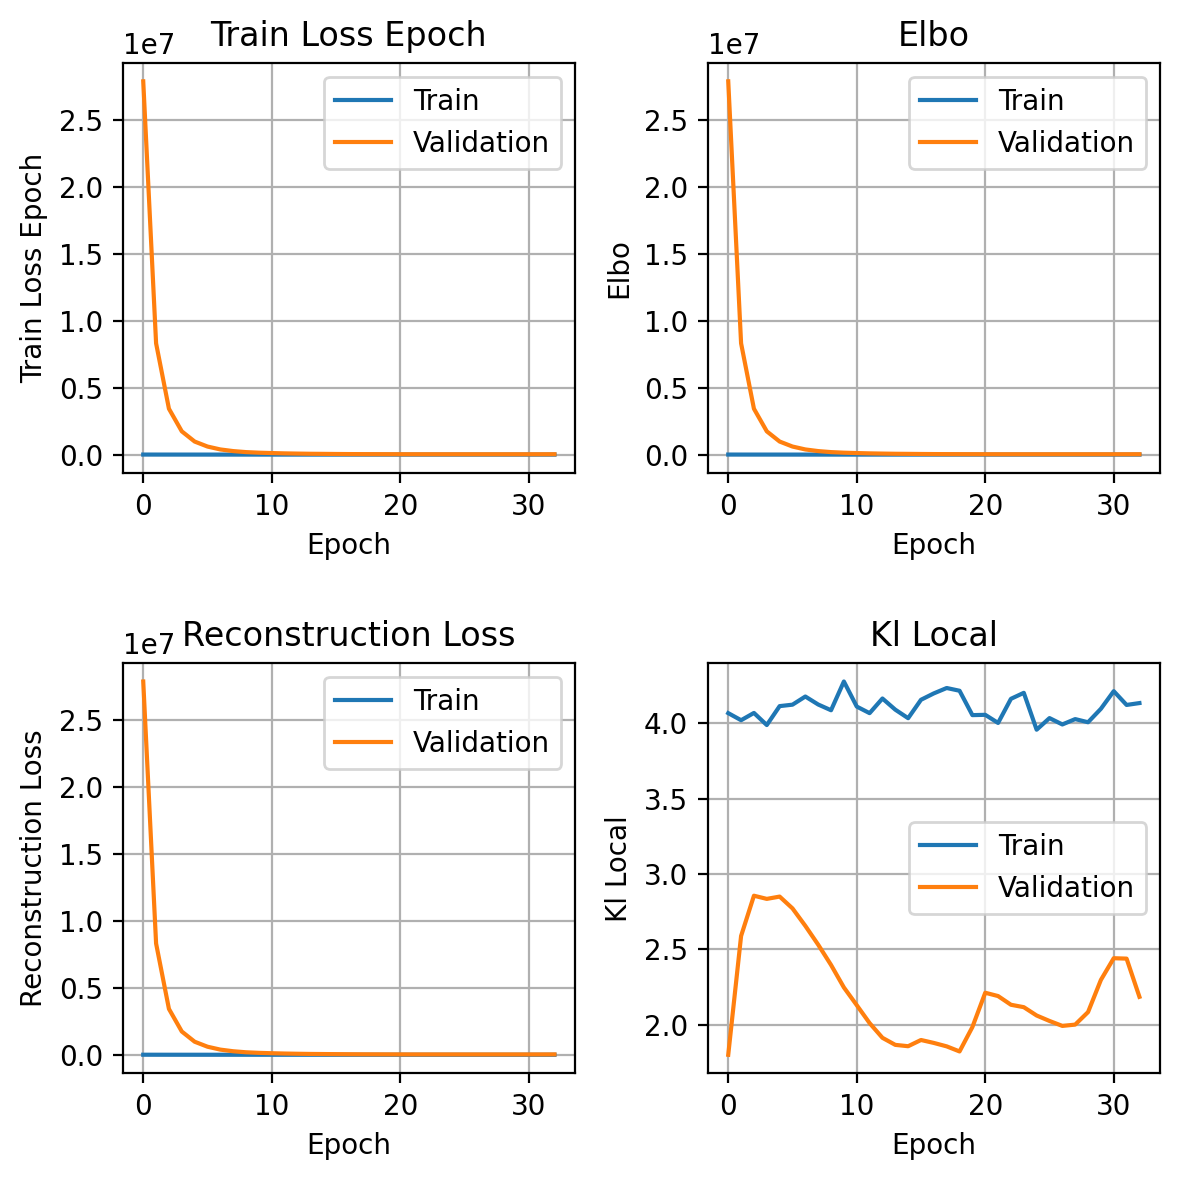

CPU times: user 2.72 s, sys: 129 ms, total: 2.85 s
Wall time: 3 s


In [42]:
%%time
batch_key = "group"

rsc.get.anndata_to_CPU(adata)
bdata = adata.copy()
bdata = bdata[:, bdata.var['filter_pass']].copy()

rsc.get.anndata_to_GPU(bdata)
rsc.pp.highly_variable_genes(
    bdata,
    flavor="seurat_v3",
    n_top_genes=2500, # If only doing embedding, can lower this; if wanting to quantify gene expression, need to increase this number
    batch_key=batch_key,
)

bdata = bdata[:, bdata.var['highly_variable']].copy()
rsc.get.anndata_to_CPU(bdata)

# scvi
scvi.model.SCVI.setup_anndata(
    bdata, 
    batch_key=batch_key,
    continuous_covariate_keys=['S_score', 'G2M_score'],
)

model = scvi.model.SCVI(
    bdata,
    n_hidden=128,
    n_latent=24, # size of latent space we're learning; too small might not be able to capture biological differences; too large might be overfitting (good between 10-36; aim for 10-15 for MYOD data)
    n_layers=2, 
    dropout_rate=0.25, # really impacts curves below
    dispersion='gene-cell',
    gene_likelihood='zinb',
)

model.train(
    max_epochs=500,
    accelerator='gpu',
    early_stopping_patience=5, # go until we reach 5 consecutive steps without learning anything new
    early_stopping=True,
    batch_size=25,
    train_size=0.9,
    plan_kwargs={"lr": 1e-4}, # learning rate -- small is careful/cautiously forward; large is wrecklessly forward, can get stuck in local minimum (good values e-2 to e-6)
)

history = model.history

metrics = [
    ("train_loss_epoch", "validation_loss"),
    ("elbo_train", "elbo_validation"),
    ("reconstruction_loss_train", "reconstruction_loss_validation"),
    ("kl_local_train", "kl_local_validation"),
]

plt.rcParams['figure.dpi'] = 200
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
axes = axes.flatten()

for i, (train_key, val_key) in enumerate(metrics):
    ax = axes[i]
    train_df = history[train_key]
    val_df = history[val_key]

    ax.plot(train_df.index, train_df[train_key], label='Train')
    ax.plot(val_df.index, val_df[val_key], label='Validation')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(train_key.replace('_train', '').replace('_', ' ').title())
    ax.set_title(train_key.replace('_train', '').replace('_', ' ').title())
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()

# Save the model

In [130]:
# %%time
# outpath = "/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/scvi/pseudobulk_model/"
# model.save(outpath, overwrite=True, save_anndata=True)

CPU times: user 38.3 ms, sys: 15.9 ms, total: 54.2 ms
Wall time: 125 ms


# Embedding

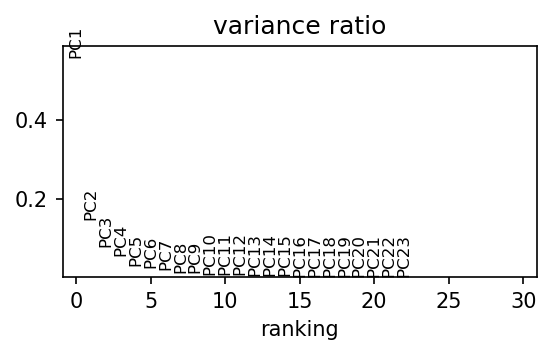

CPU times: user 98.4 ms, sys: 22.7 ms, total: 121 ms
Wall time: 125 ms


In [43]:
%%time 

embed = model.get_latent_representation()
embed = sc.AnnData(embed, obs=adata.obs)

rsc.get.anndata_to_GPU(embed)
rsc.pp.pca(embed)

plt.rcParams['figure.dpi'] = 150
plt.rcParams['figure.figsize'] = 4, 2
sc.pl.pca_variance_ratio(embed)

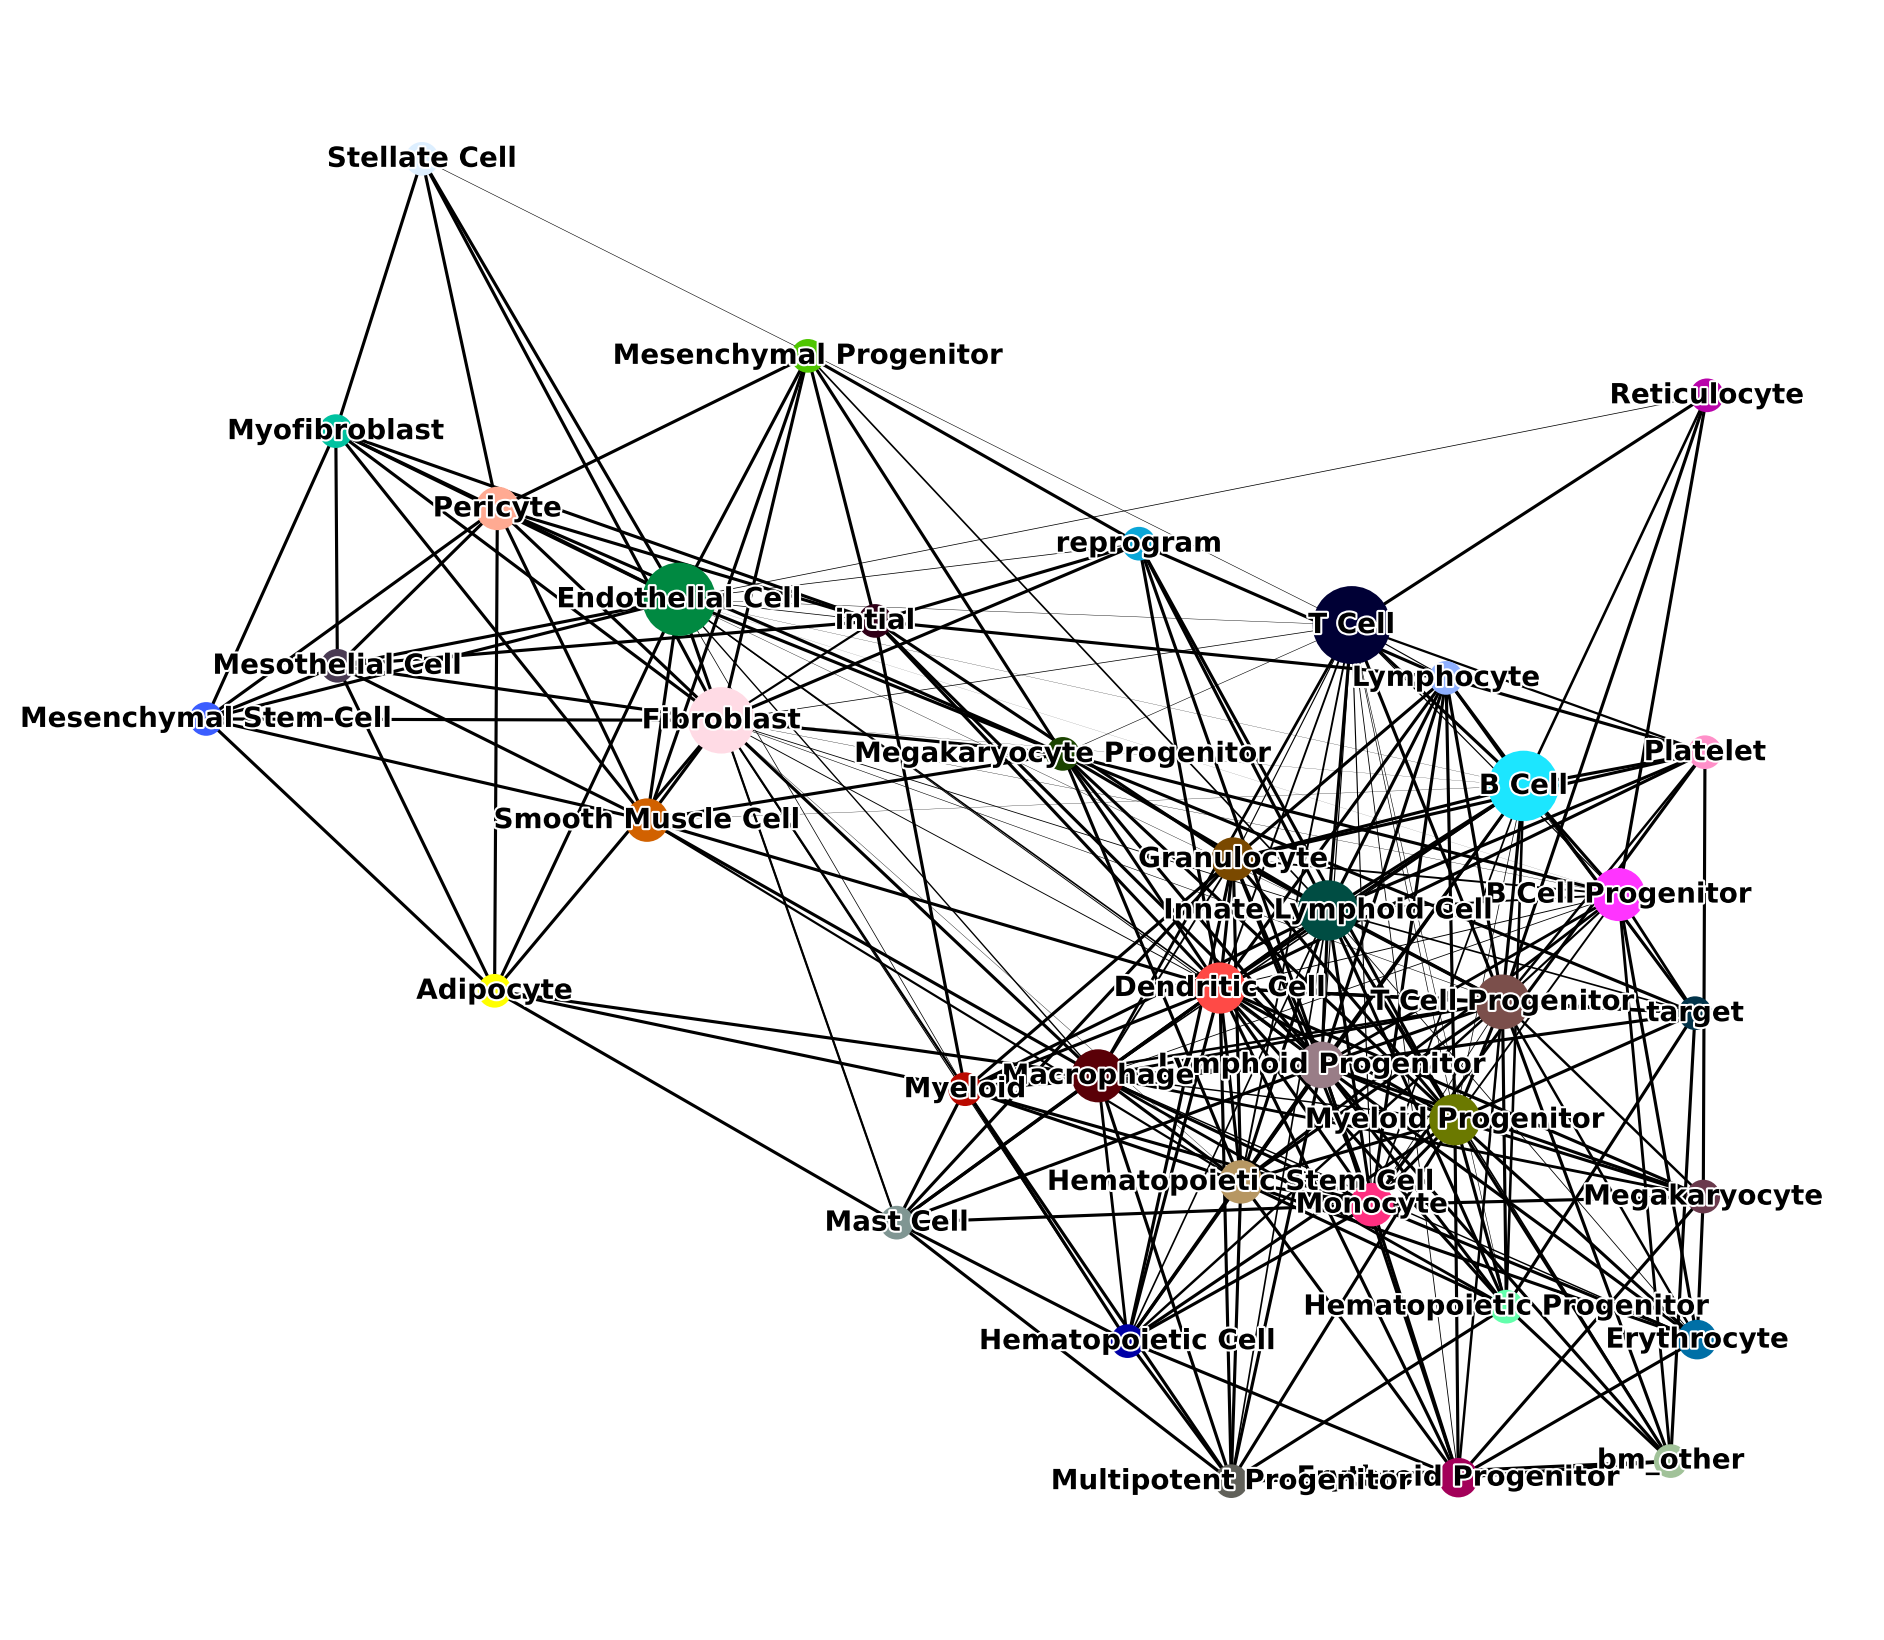

CPU times: user 436 ms, sys: 46.9 ms, total: 483 ms
Wall time: 530 ms


In [44]:
%%time
n_neighbors = 15
paga_group_column = "level3"
n_pcs = 50

rsc.pp.neighbors(
    embed, 
    n_pcs=n_pcs, 
    n_neighbors=n_neighbors,
)

# plot the embedding
sc.tl.paga(embed, groups=paga_group_column)

plt.rcParams['figure.dpi'] = 200
plt.rcParams['figure.figsize'] = 10, 10
sc.pl.paga(
    embed, 
    fontoutline=1.5, 
    edge_width_scale=0.15,  
    frameon=False,          
)

embed.obsm['X_paga'] = get_init_pos_from_paga(embed)

# Save as h5ad at this point to Turbo

In [20]:
# embed.write_h5ad("/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/scvi/pseudobulk_model/fig4_embed.h5ad")

Graph with 38 nodes and 274 edges


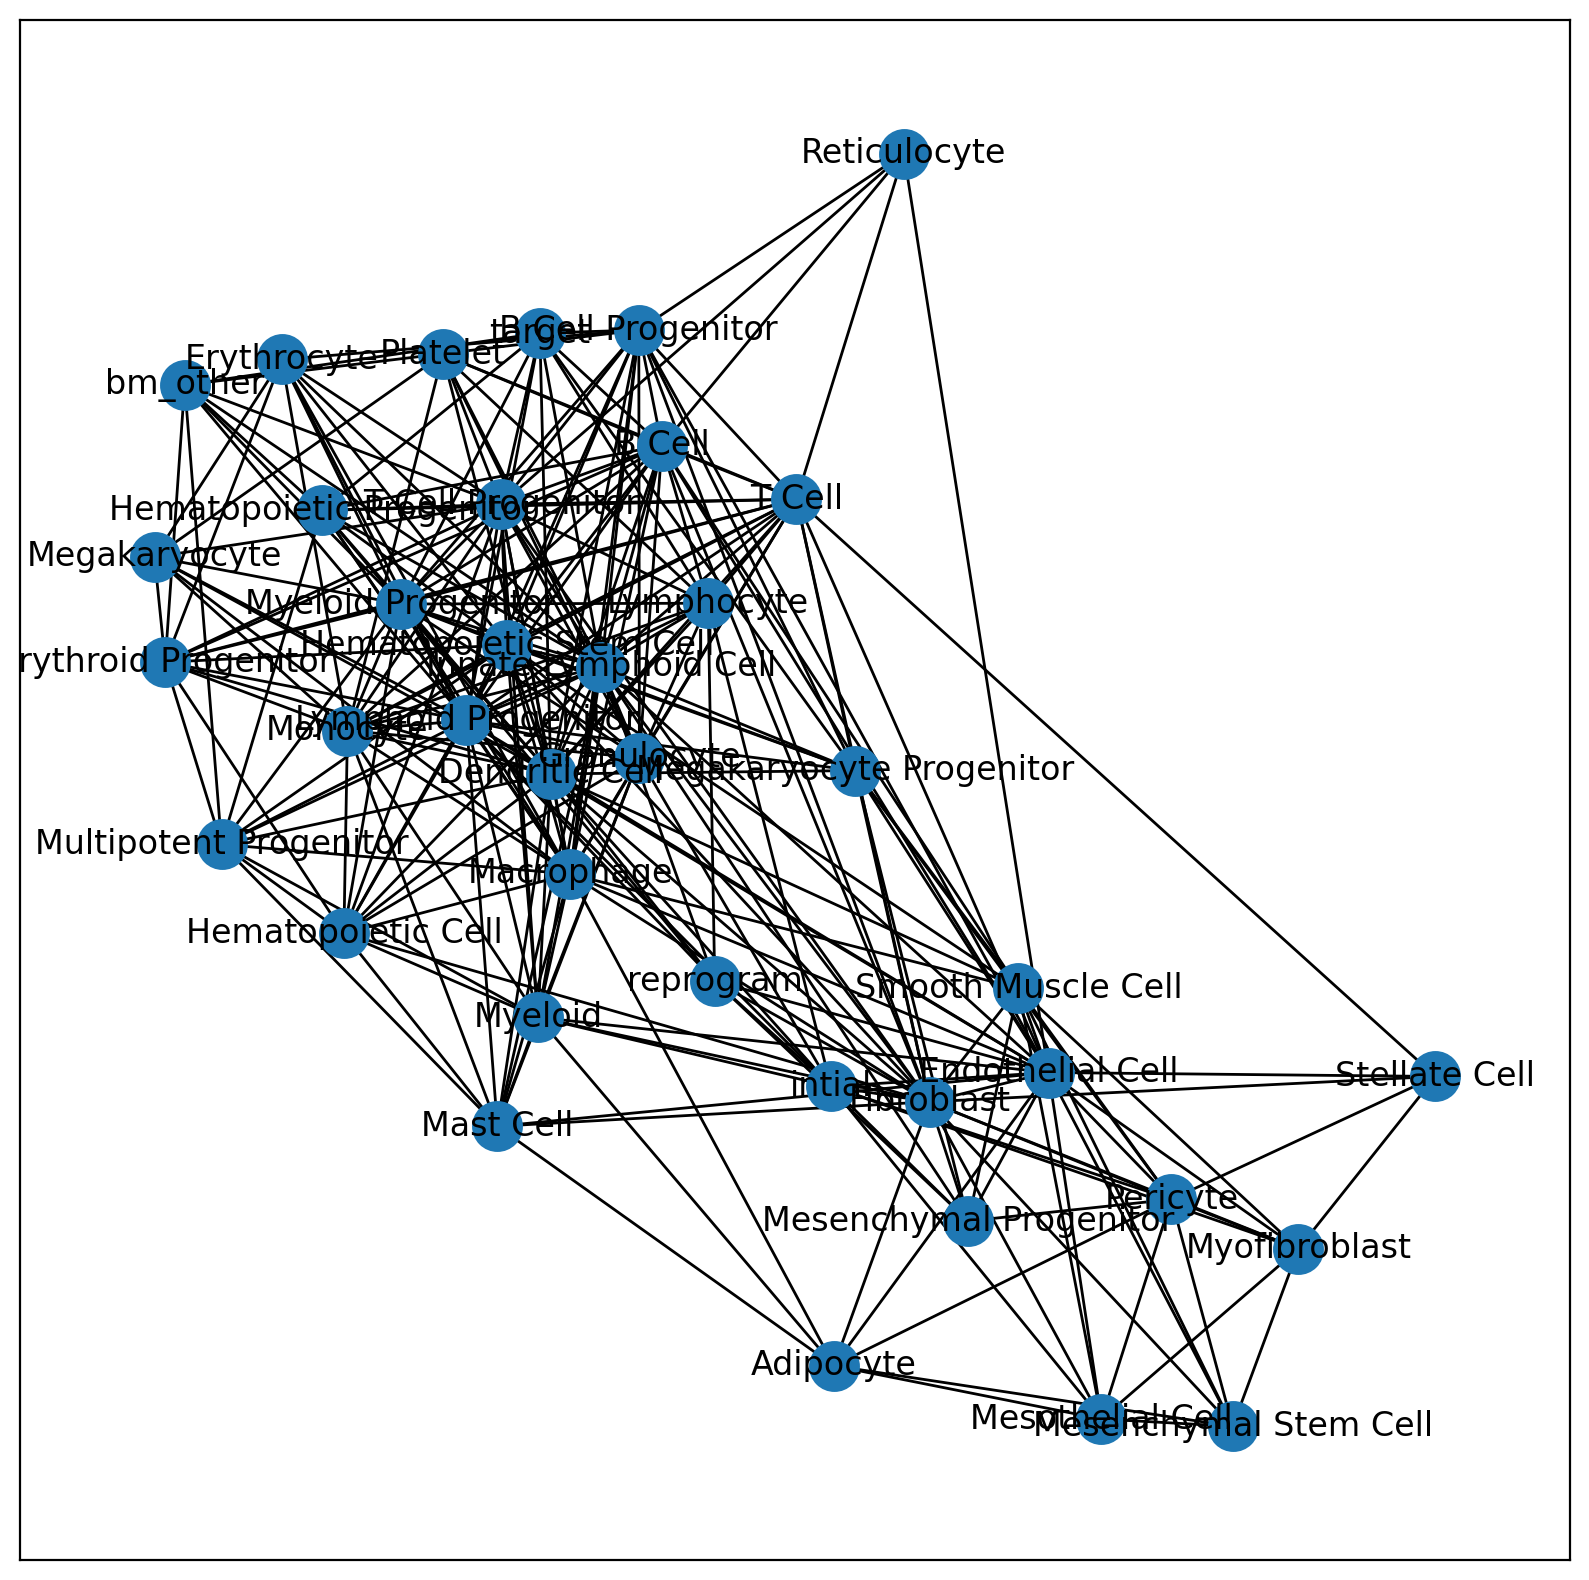

In [45]:
def paga_to_networkx(adata):
    """
    Build a NetworkX graph from adata.uns['paga'].
    
        
    Returns
    -------
    G : networkx.Graph
        Weighted undirected graph (nodes = clusters, edges = PAGA connectivity).
    """
    # Get PAGA connectivity and cluster names
    conn = adata.uns['paga']['connectivities']
    group_key = adata.uns['paga']['groups']
    clusters = adata.obs[group_key].cat.categories

    matrix = pd.DataFrame(
        adata.uns['paga']['connectivities'].todense().copy(),
        index=clusters.values,
        columns=clusters.values,
    )

    G = nx.from_pandas_adjacency(matrix)
    G.pos = adata.uns['paga']['pos'].copy()
    return G

G = paga_to_networkx(embed)
print(G)
nx.draw_networkx(G)

In [13]:
print(list(embed.obs[paga_group_column].unique()))

['bm_other', 'intial', 'reprogram', 'target', 'B Cell', 'Dendritic Cell', 'T Cell', 'T Cell Progenitor', 'Innate Lymphoid Cell', 'Hematopoietic Stem Cell', 'Lymphoid Progenitor', 'Adipocyte', 'Macrophage', 'Fibroblast', 'Granulocyte', 'Myeloid Progenitor', 'Endothelial Cell', 'Smooth Muscle Cell', 'Monocyte', 'Erythroid Progenitor', 'Erythrocyte', 'Mesenchymal Progenitor', 'B Cell Progenitor', 'Hematopoietic Cell', 'Multipotent Progenitor', 'Hematopoietic Progenitor', 'Stellate Cell', 'Pericyte', 'Lymphocyte', 'Mast Cell', 'Megakaryocyte', 'Megakaryocyte Progenitor', 'Mesenchymal Stem Cell', 'Mesothelial Cell', 'Myeloid', 'Myofibroblast', 'Platelet', 'Reticulocyte']


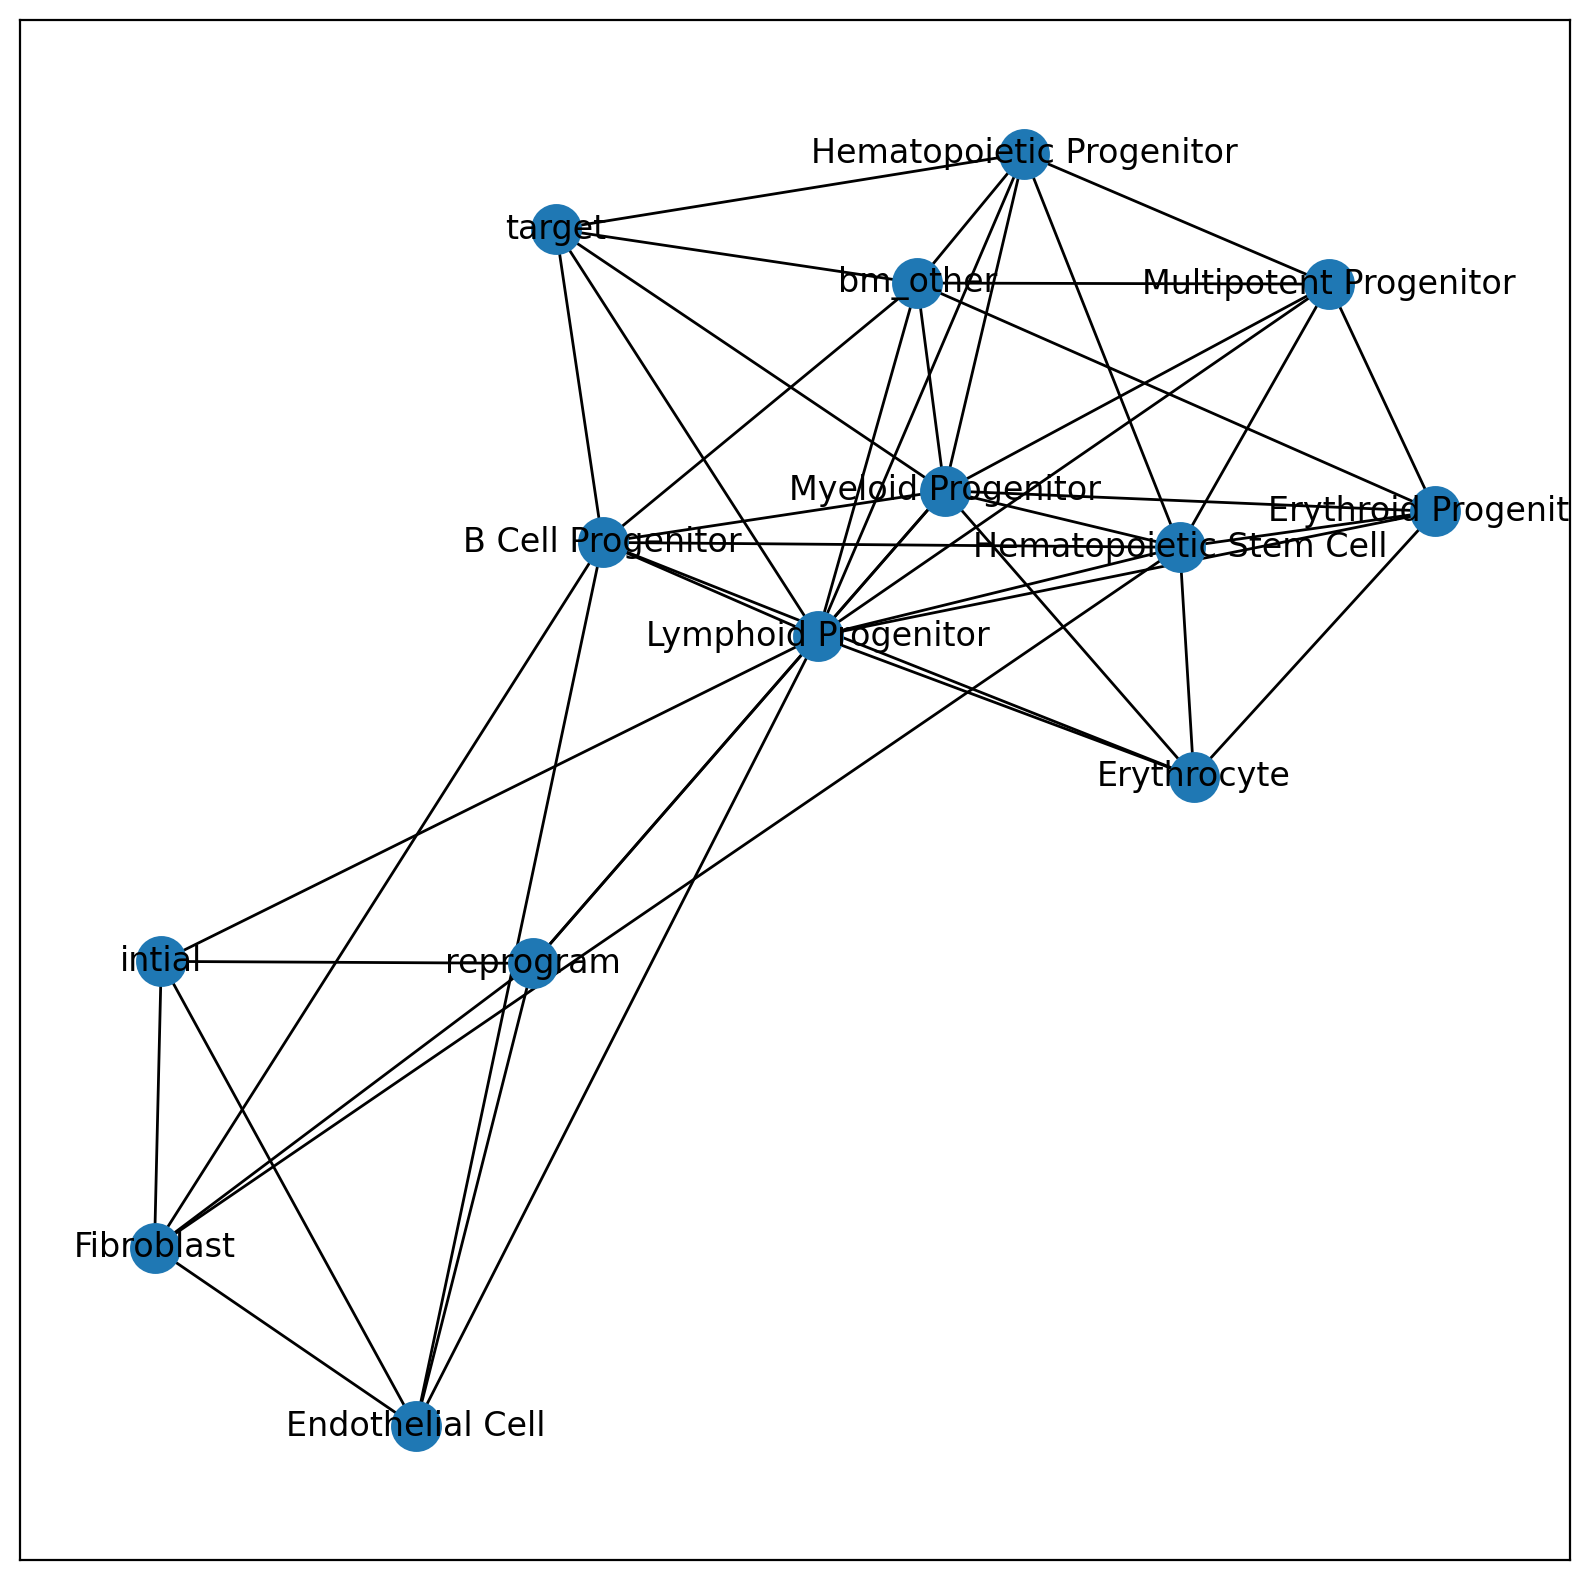

In [46]:
keep = [
    'bm_other',
    'intial',
    'reprogram',
    'target',
    'Hematopoietic Stem Cell',
    'Lymphoid Progenitor',
    'Fibroblast',
    'Myeloid Progenitor',
    'Endothelial Cell',
    # 'Smooth Muscle Cell',
    'Erythroid Progenitor',
    'Erythrocyte',
    # 'Mesenchymal Progenitor',
    'B Cell Progenitor',
    'Multipotent Progenitor',
    'Hematopoietic Progenitor',
    # 'Megakaryocyte',
    # 'Megakaryocyte Progenitor',
    # 'Mesenchymal Stem Cell',
]

G.remove_nodes_from([n for n in G.nodes() if n not in keep])
nx.draw_networkx(G)

In [25]:
# import pickle

# with open('/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/scvi/pseudobulk_model/fig4_embed_graph.pkl', 'wb') as f:
#     pickle.dump(G, f)

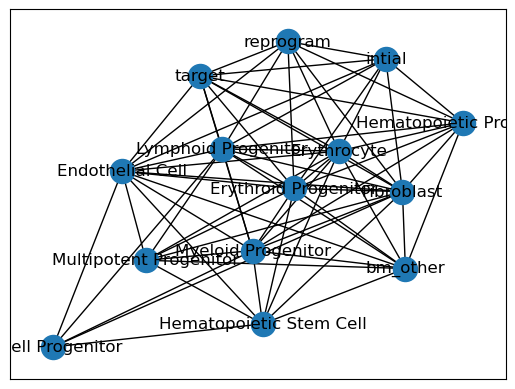

In [3]:
# import pickle

# with open('/nfs/turbo/umms-indikar/shared/projects/HSC/pipeline_outputs/scvi/pseudobulk_model/fig4_embed_graph.pkl', 'rb') as f:
#     G = pickle.load(f)

# nx.draw_networkx(G)

In [19]:
G.nodes

NodeView(('B Cell Progenitor', 'Endothelial Cell', 'Erythrocyte', 'Erythroid Progenitor', 'Fibroblast', 'Hematopoietic Progenitor', 'Hematopoietic Stem Cell', 'Lymphoid Progenitor', 'Multipotent Progenitor', 'Myeloid Progenitor', 'bm_other', 'intial', 'reprogram', 'target'))

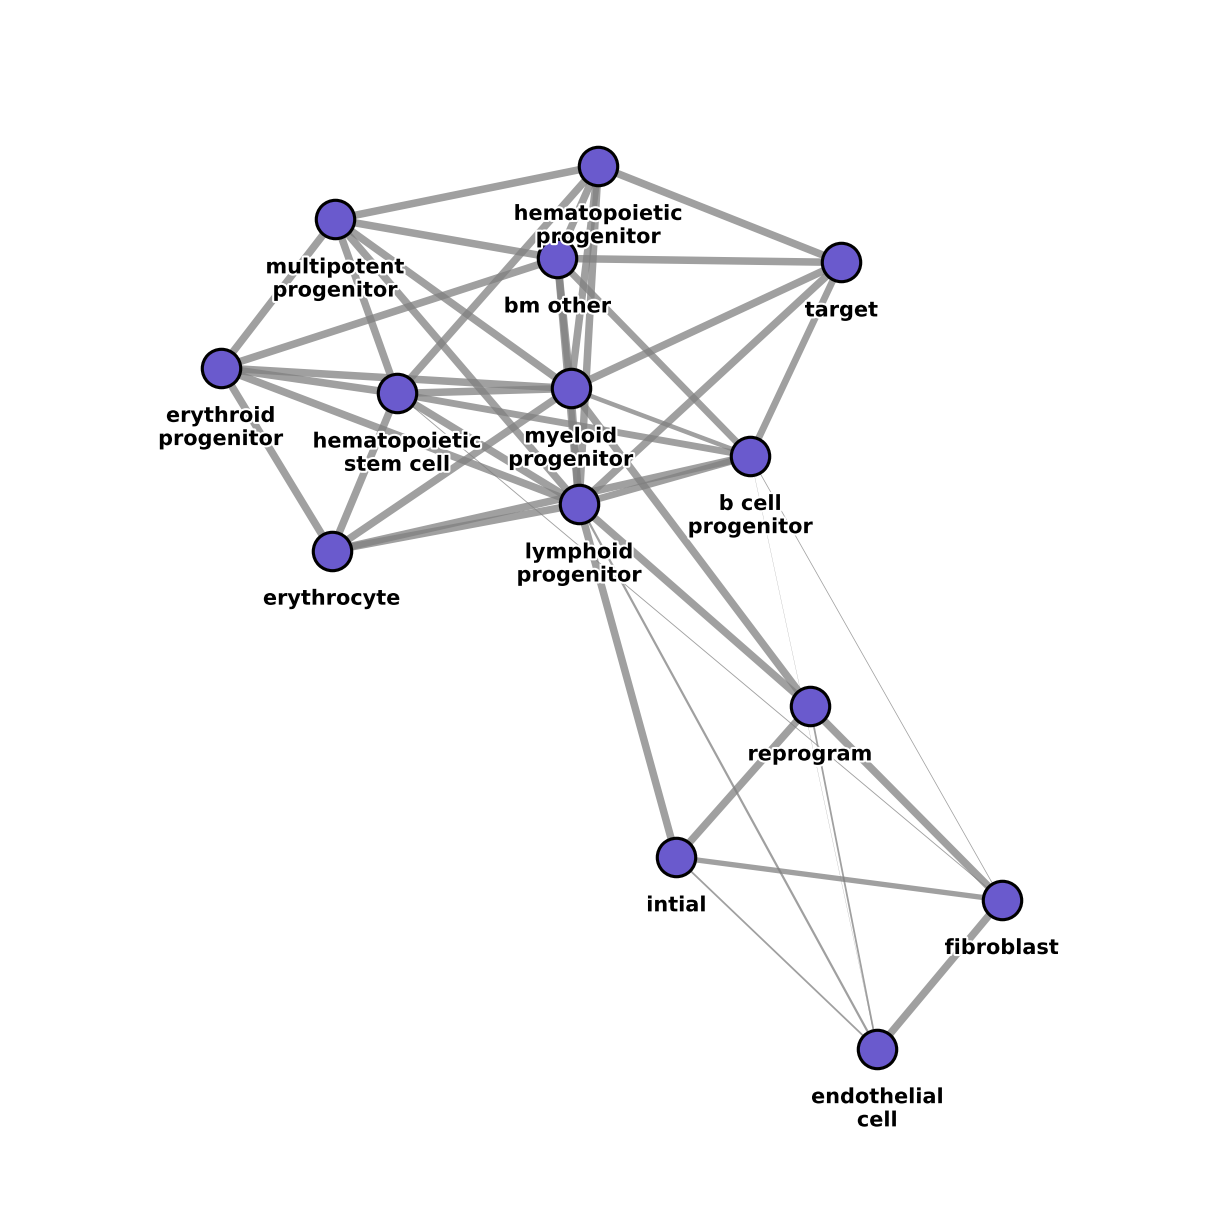

In [50]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 5, 5

# Plot
pos = nx.spring_layout(G, seed=0)#, scale=1.5)
# pos = nx.bfs_layout(G, start='reprogram')
# pos = nx.arf_layout(G)

# pos_flipped = {node: (x, -y) for node, (x, y) in pos.items()}

# pos_rotated = rotate_layout(pos_flipped, angle_deg=130) # 30

# pos = pos_rotated.copy()

edges, weights = zip(*nx.get_edge_attributes(G, 'weight').items())

nx.draw_networkx_edges(
    G, 
    pos,
    edgelist=edges,
    edge_color='grey',
    alpha=0.75,
    width=np.array(weights)*1.8,
)

nx.draw_networkx_nodes(
    G, pos, 
    node_color='slateblue', 
    node_size=85, 
    edgecolors='black',   
    linewidths=0.75
)

# Draw labels with white border (stroke)
# label_dict = {n: n.lower().replace("_", " ") for n in G.nodes}

label_dict = {}
for n in G.nodes:
    label = n.lower().replace("_", " ")
    
    # Move "progenitor" to a new line if present
    if "progenitor" in label:
        label = label.replace(" progenitor", "\nprogenitor")
    
    # Move "stem cell" to a new line if present
    if "hematopoietic stem cell" in label:
        label = label.replace("hematopoietic stem cell", "hematopoietic\nstem cell")
        
    if "endothelial cell" in label:
        label = label.replace(" cell", "\ncell")
    
    label_dict[n] = label



# how much to shift down in layout‐units:
y_off = 0.07

# build new label positions
label_pos = {n: (x, y - y_off) for n, (x, y) in pos.items()}

# then draw labels at the shifted locations
labels = nx.draw_networkx_labels(
    G,
    label_pos,
    labels=label_dict,
    font_size=5,
    font_weight='bold',
    verticalalignment='top'  # keep the text anchored at its top
)

for _, t in labels.items():
    t.set_path_effects([
        pe.Stroke(linewidth=1, foreground='white'),
        pe.Normal()
    ])

plt.axis('off')
xs, ys = zip(*pos.values())
pad = 0.25
ax = plt.gca()
ax.set_xlim(min(xs)-pad, max(xs)+pad)
ax.set_ylim(min(ys)-pad, max(ys)+pad)
# ax.set_facecolor('none')    # axes background
# plt.gcf().set_facecolor('none')    # figure background
plt.show()


In [67]:
import math

def rotate_layout(pos, angle_deg):
    angle_rad = math.radians(-angle_deg)  # negative for clockwise
    cos_a = math.cos(angle_rad)
    sin_a = math.sin(angle_rad)

    return {
        node: (x * cos_a - y * sin_a, x * sin_a + y * cos_a)
        for node, (x, y) in pos.items()
    }

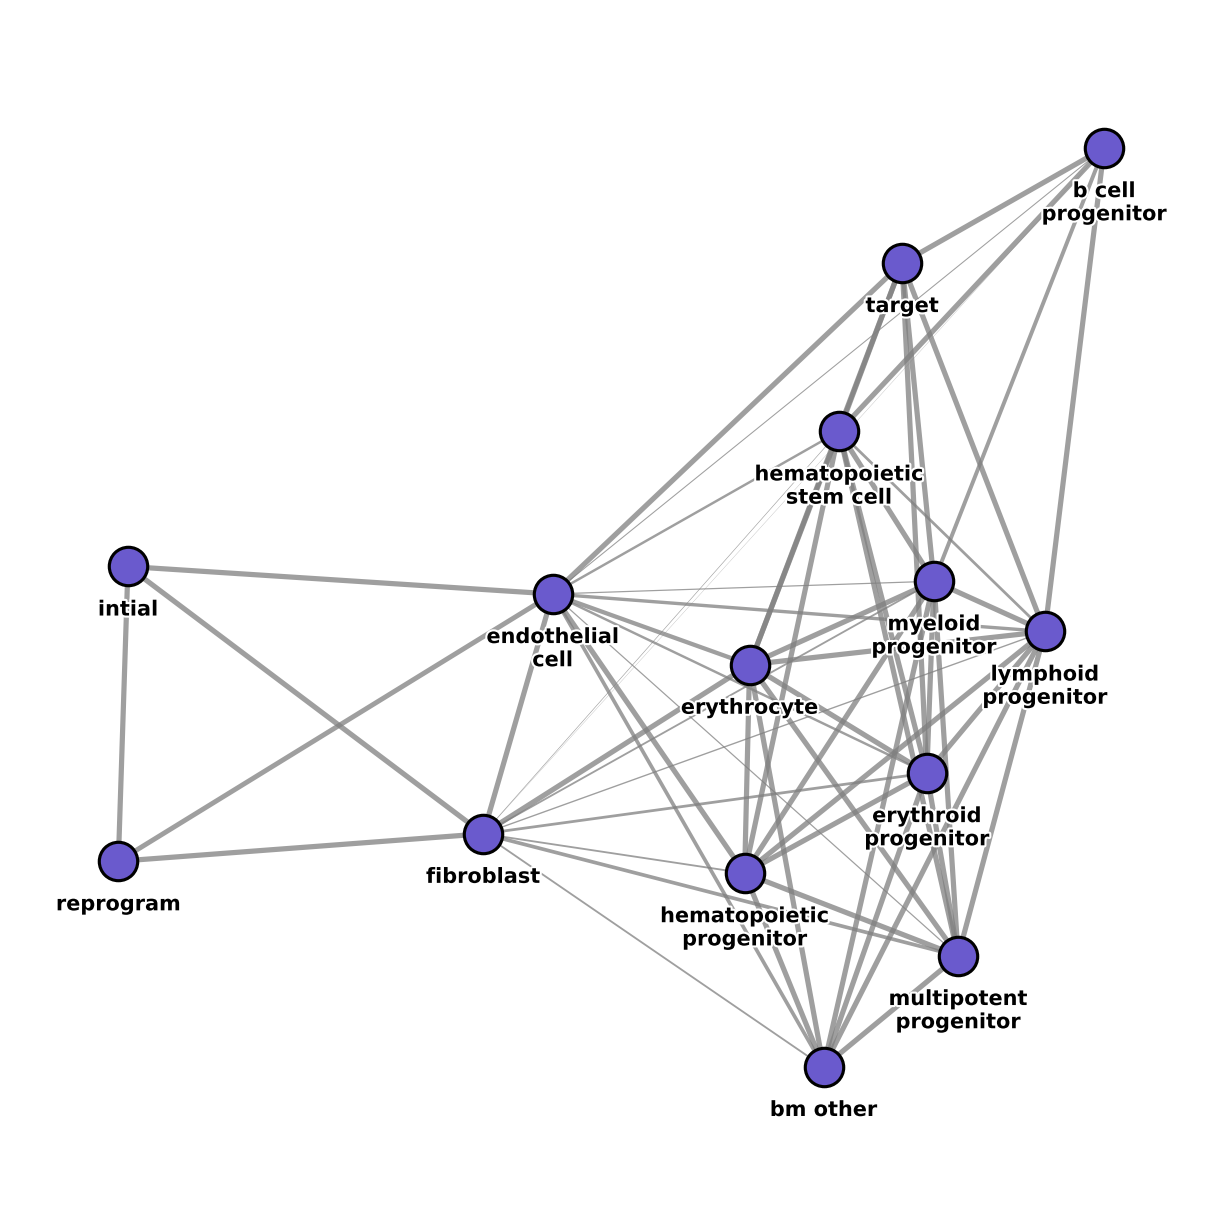

In [81]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 5, 5

# Plot
pos = nx.spring_layout(G, seed=1, scale=1.5)

pos_flipped = {node: (x, -y) for node, (x, y) in pos.items()}

pos_rotated = rotate_layout(pos_flipped, angle_deg=130) # 30

pos = pos_rotated.copy()

edges, weights = zip(*nx.get_edge_attributes(G, 'weight').items())

nx.draw_networkx_edges(
    G, 
    pos,
    edgelist=edges,
    edge_color='grey',
    alpha=0.75,
    width=np.array(weights)*1.25,
)

nx.draw_networkx_nodes(
    G, pos, 
    node_color='slateblue', 
    node_size=85, 
    edgecolors='black',   
    linewidths=0.75
)

# Draw labels with white border (stroke)
# label_dict = {n: n.lower().replace("_", " ") for n in G.nodes}

label_dict = {}
for n in G.nodes:
    label = n.lower().replace("_", " ")
    
    # Move "progenitor" to a new line if present
    if "progenitor" in label:
        label = label.replace(" progenitor", "\nprogenitor")
    
    # Move "stem cell" to a new line if present
    if "hematopoietic stem cell" in label:
        label = label.replace("hematopoietic stem cell", "hematopoietic\nstem cell")
        
    if "endothelial cell" in label:
        label = label.replace(" cell", "\ncell")
    
    label_dict[n] = label



# how much to shift down in layout‐units:
y_off = 0.07

# build new label positions
label_pos = {n: (x, y - y_off) for n, (x, y) in pos.items()}

# then draw labels at the shifted locations
labels = nx.draw_networkx_labels(
    G,
    label_pos,
    labels=label_dict,
    font_size=5,
    font_weight='bold',
    verticalalignment='top'  # keep the text anchored at its top
)

for _, t in labels.items():
    t.set_path_effects([
        pe.Stroke(linewidth=1, foreground='white'),
        pe.Normal()
    ])

plt.axis('off')
xs, ys = zip(*pos.values())
pad = 0.25
ax = plt.gca()
ax.set_xlim(min(xs)-pad, max(xs)+pad)
ax.set_ylim(min(ys)-pad, max(ys)+pad)
ax.set_facecolor('none')    # axes background
plt.gcf().set_facecolor('none')    # figure background
plt.show()


In [27]:
label_dict

{'B Cell Progenitor': 'b cell progenitor',
 'Endothelial Cell': 'endothelial cell',
 'Erythrocyte': 'erythrocyte',
 'Erythroid Progenitor': 'erythroid progenitor',
 'Fibroblast': 'fibroblast',
 'Hematopoietic Progenitor': 'hematopoietic progenitor',
 'Hematopoietic Stem Cell': 'hematopoietic stem cell',
 'Lymphoid Progenitor': 'lymphoid progenitor',
 'Multipotent Progenitor': 'multipotent progenitor',
 'Myeloid Progenitor': 'myeloid progenitor',
 'bm_other': 'bm other',
 'intial': 'intial',
 'reprogram': 'reprogram',
 'target': 'target'}

# Distance Matrix:

In [32]:
%%time
X = embed.obsm['X_pca']
print(f"{X.shape=}")

dists = pairwise_distances(X, metric='euclidean')
print(f"{dists.shape=}")

df = pd.DataFrame(
    dists, 
    index=embed.obs['level3'].values,
    columns=embed.obs['level3'].values,
)

df = df.groupby(level=0, axis=0).mean().groupby(level=0, axis=1).mean()
df = df[keep].loc[keep]
df = (df - df.values.min()) / (df.values.max() - df.values.min())
df.index = df.index.str.lower().str.replace("_", " ")
df.columns = df.columns.str.lower().str.replace("_", " ")
print(f"{df.shape=}")

df.head()

X.shape=(192, 23)
dists.shape=(192, 192)
df.shape=(14, 14)
CPU times: user 8.27 ms, sys: 2.05 ms, total: 10.3 ms
Wall time: 13.4 ms


<timed exec>:13: FutureWarning: The 'axis' keyword in DataFrame.groupby is deprecated and will be removed in a future version.
<timed exec>:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
<timed exec>:13: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.


,bm other,intial,reprogram,target,hematopoietic stem cell,lymphoid progenitor,fibroblast,myeloid progenitor,endothelial cell,erythroid progenitor,erythrocyte,b cell progenitor,multipotent progenitor,hematopoietic progenitor
bm other,0.000000,0.772097,0.852034,0.313953,0.427272,0.358567,0.550951,0.276836,0.455099,0.340928,0.310719,0.491230,0.294988,0.205522
intial,0.772097,0.000000,0.183281,0.720031,0.849148,0.846024,0.679112,0.747607,0.743268,0.812090,0.669835,0.717739,0.918754,0.872770
reprogram,0.852034,0.183281,0.000000,0.809820,0.937285,0.941663,0.745910,0.834158,0.833960,0.885263,0.748955,0.807770,1.000000,0.967938
target,0.313953,0.720031,0.809820,0.000000,0.407470,0.316609,0.492874,0.312621,0.383560,0.437915,0.354762,0.341476,0.527763,0.357427
hematopoietic stem cell,0.427272,0.849148,0.937285,0.407470,0.379794,0.474329,0.632338,0.422209,0.515935,0.478365,0.453013,0.451951,0.481919,0.445512


Text(143.66666666666666, 0.5, '')

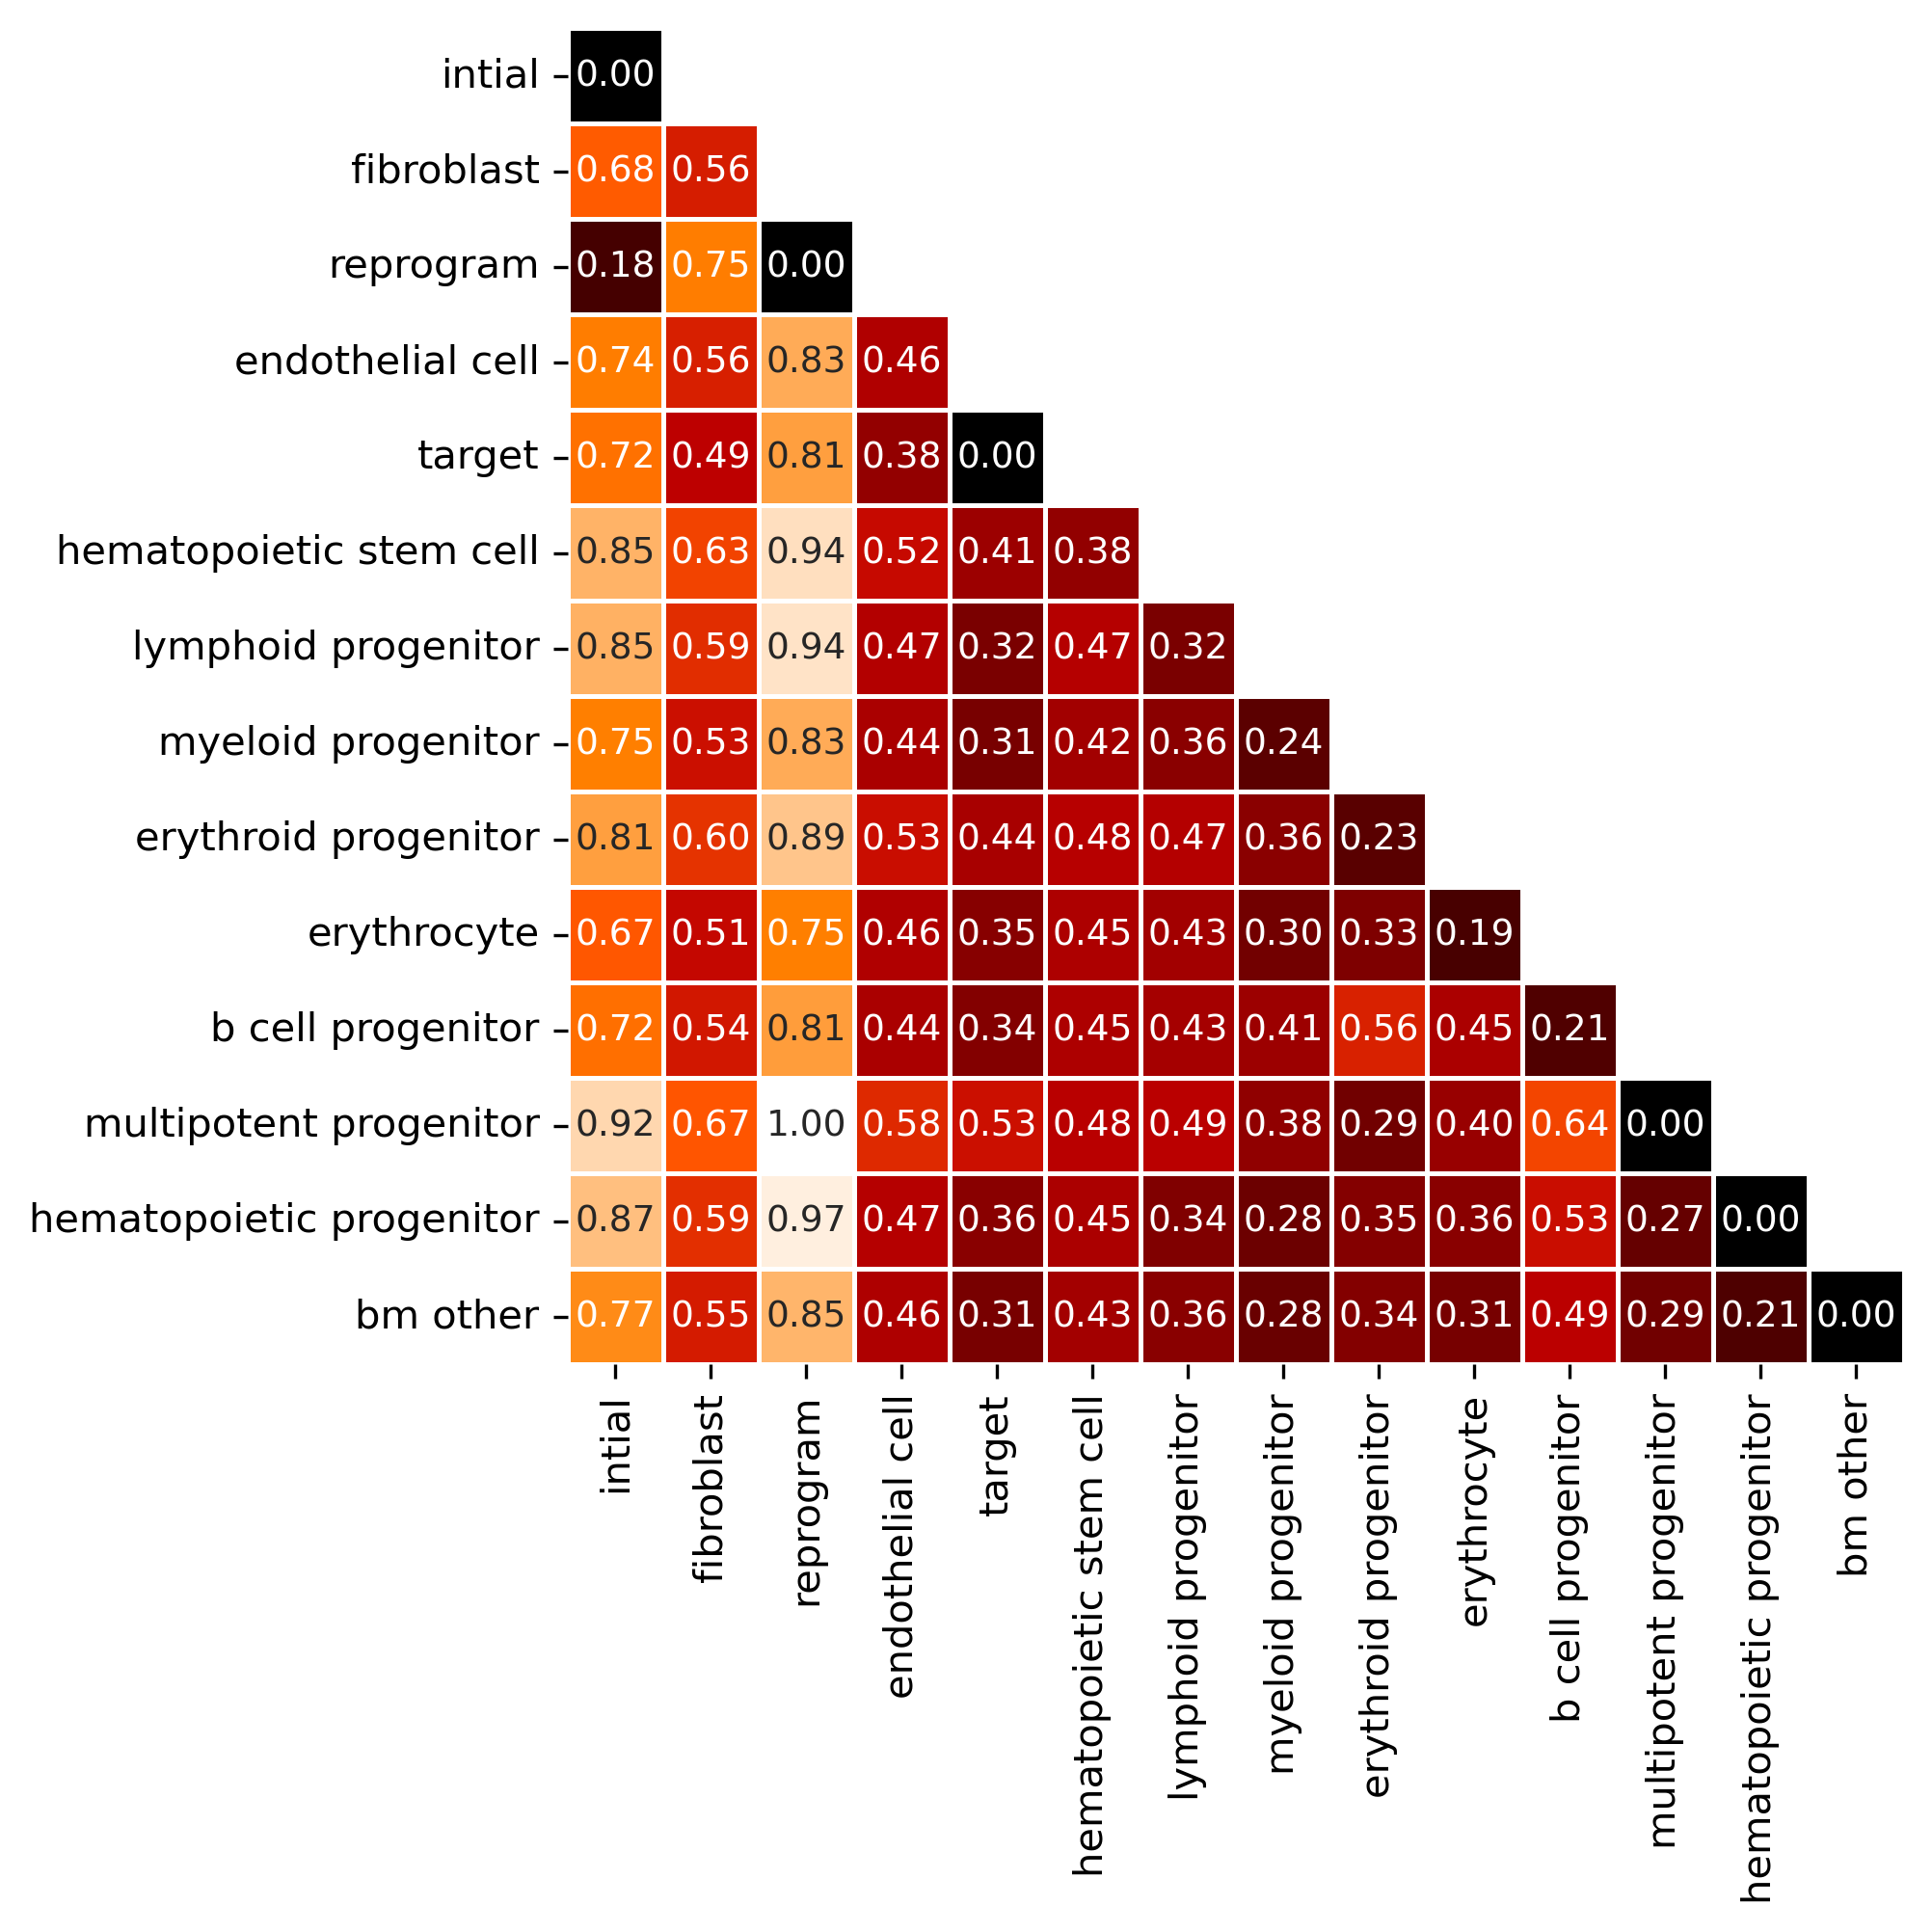

In [34]:
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 6, 6

order = [
    'intial', 
    'fibroblast',
    'reprogram', 
    'endothelial cell', 
    'target',
    'hematopoietic stem cell',
    'lymphoid progenitor',  
    'myeloid progenitor',
    'erythroid progenitor',
    'erythrocyte',
    'b cell progenitor',
    'multipotent progenitor',
    'hematopoietic progenitor',
    'bm other',     
]

pdf = df.copy()

# establish sort order
pdf = pdf[order].reindex(order)
mask = np.triu(np.ones_like(pdf, dtype=bool), k=1)

sns.heatmap(
    pdf, square=True,
    mask=mask,
    cmap='gist_heat',
    linewidth=0.75,
    annot=True,
    fmt=".2f",
    annot_kws={'fontsize' : 9},
    cbar=False,
    vmin=0, 
    vmax=1,
)

# plt.xticks([])
plt.xlabel("")
plt.ylabel("")

In [15]:
# break

SyntaxError: 'break' outside loop (668683560.py, line 1)

In [ ]:
def paga_to_networkx(adata):
    """
    Build a NetworkX graph from adata.uns['paga'].
    
        
    Returns
    -------
    G : networkx.Graph
        Weighted undirected graph (nodes = clusters, edges = PAGA connectivity).
    """
    # Get PAGA connectivity and cluster names
    conn = adata.uns['paga']['connectivities']
    group_key = adata.uns['paga']['groups']
    clusters = adata.obs[group_key].cat.categories

    matrix = pd.DataFrame(
        adata.uns['paga']['connectivities'].todense().copy(),
        index=clusters.values,
        columns=clusters.values,
    )

    G = nx.from_pandas_adjacency(matrix)
    G.pos = adata.uns['paga']['pos'].copy()
    return G

G = paga_to_networkx(embed)
G.remove_node('Hematopoietic Cell')

# Node colors: one color per node
node_colors = plt.cm.tab20(np.linspace(0, 1, len(G.nodes)))

plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = 6, 6

# Plot
pos = nx.spring_layout(G, seed=0)
edges, weights = zip(*nx.get_edge_attributes(G, 'weight').items())

nx.draw_networkx_edges(G, pos, edgelist=edges, edge_color='grey', width=3*np.array(weights))
nx.draw_networkx_nodes(
    G, pos, 
    node_color=node_colors, 
    node_size=800, 
    edgecolors='black',   # node outline
    linewidths=1
)

# Draw labels with white border (stroke)
label_dict = {n: n for n in G.nodes}
labels = nx.draw_networkx_labels(
    G, pos, labels=label_dict, font_size=8, font_weight='bold',
)

for _, t in labels.items():
    t.set_path_effects([
        pe.Stroke(linewidth=1, foreground='white'),
        pe.Normal()
    ])

plt.axis('off')
plt.tight_layout()
plt.show()